<h2><font color="#004D7F" size=6>Módulo 3. Machine Learning</font></h2>

<h1><font color="#004D7F" size=5>1. Algoritmo KNN </font></h1>

<h1><font color="#004D7F" size=5>2. Taller de  Creditos Bancarios </font></h1>
<br>
<div style="text-align: right">
<font color="#004D7F" size=3>Seminario en Ciencia de Datos</font><br>

In [4]:
#Importamos las librerias requeridas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier

In [6]:
#Leemos el archivo de creditos
clientes = pd.read_csv("creditos.csv")
clientes

,edad,credito,cumplio
0,18,363112,0
1,19,477965,1
2,20,239072,0
3,22,195265,0
4,22,482174,0
...,...,...,...
195,55,100000,0
196,55,523144,0
197,55,543771,0
198,56,285288,0


<BR><BR>

# Pagadores VS Deudores

In [10]:
buenos = clientes[clientes["cumplio"]==1]
malos = clientes[clientes["cumplio"]==0]
malos

,edad,credito,cumplio
0,18,363112,0
2,20,239072,0
3,22,195265,0
4,22,482174,0
5,23,468815,0
9,24,246195,0
10,24,433444,0
11,25,100000,0
12,25,161474,0
40,28,432323,0


# Gráfica: Pagadores VS Deudores

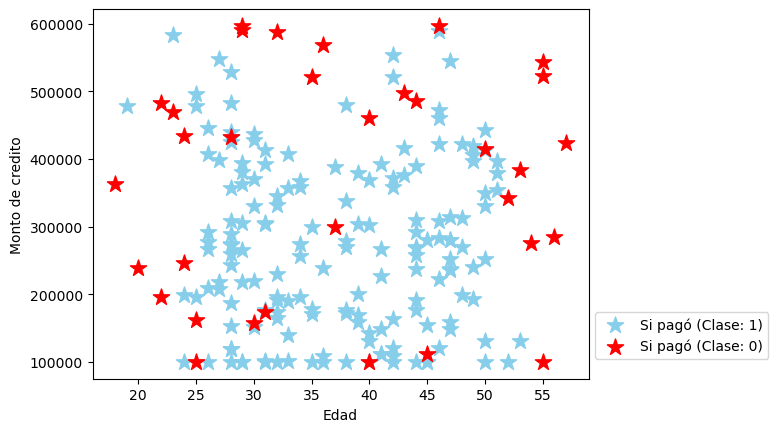

In [18]:
plt.scatter(buenos["edad"], buenos["credito"],
          marker="*", s=150, color="skyblue",
          label="Si pagó (Clase: 1)")

plt.scatter(malos["edad"], malos["credito"],
          marker="*", s=150, color="red",
          label="Si pagó (Clase: 0)")

plt.ylabel("Monto de credito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1,0.2))
plt.show()

<BR><BR>

<BR><BR>

# Preparación de los datos (Escalar)

In [20]:
#datos
datos = clientes[["edad","credito"]]
clase = clientes["cumplio"]

escalador = preprocessing.MinMaxScaler()

datos = escalador.fit_transform(datos) # Para que nuestros valores esten en el rango de 0 y 1
datos

array([[0.        , 0.52964444],
       [0.02564103, 0.76084353],
       [0.05128205, 0.27995193],
       [0.1025641 , 0.19176844],
       [0.1025641 , 0.76931624],
       [0.12820513, 0.74242458],
       [0.12820513, 0.97341632],
       [0.15384615, 0.        ],
       [0.15384615, 0.19983453],
       [0.15384615, 0.29429053],
       [0.15384615, 0.67122276],
       [0.17948718, 0.        ],
       [0.17948718, 0.12374716],
       [0.17948718, 0.19192143],
       [0.17948718, 0.76130249],
       [0.17948718, 0.79673129],
       [0.20512821, 0.        ],
       [0.20512821, 0.21862589],
       [0.20512821, 0.33577846],
       [0.20512821, 0.35571521],
       [0.20512821, 0.38628463],
       [0.20512821, 0.61926119],
       [0.20512821, 0.69480706],
       [0.23076923, 0.21664509],
       [0.23076923, 0.23805134],
       [0.23076923, 0.60140789],
       [0.23076923, 0.90058196],
       [0.25641026, 0.        ],
       [0.25641026, 0.03816245],
       [0.25641026, 0.03904616],
       [0.

In [11]:
#datos

<BR><BR>

# Creación del Modelo KNN
## Valor de K

In [24]:
#Una forma de obtener el numero de k vecino es sacando la raiz cuadrada de numero de registros
clasificador = KNeighborsClassifier(n_neighbors=3)

#El fit permite crear nuestro modelo de clasificación
clasificador.fit(datos,clase)

KNeighborsClassifier(n_neighbors=3)

<BR><BR>

# Nuevo Solicitante (Clasificación)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Clase: [0]
Probabilidad por clase [[0.66666667 0.33333333]]


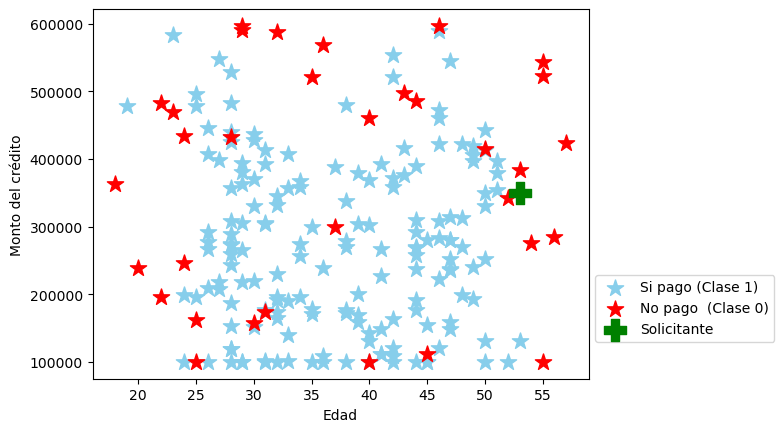

In [32]:
edad = 53
monto = 350000

# Escalando los datos del nuevo solicitante
solicitante = escalador.transform([[edad,monto]])

print("Clase:", clasificador.predict(solicitante))

print("Probabilidad por clase",clasificador.predict_proba(solicitante) )


#Codigo de grafica
plt.scatter(buenos["edad"], buenos["credito"],
           marker="*", s=150, color="skyblue", 
           label ="Si pago (Clase 1)")

plt.scatter(malos["edad"], malos["credito"],
           marker="*", s=150, color="red", 
           label ="No pago  (Clase 0)")

plt.scatter(edad, monto, marker="P", s=250, color="green", label="Solicitante")
plt.ylabel("Monto del crédito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1,0.3))
plt.show()

<BR><BR>

# Regiones de las clases
### Pagadores vs Deudores

Registros generados = 43*501

In [62]:
#Crear datos sinteticos con Numpy
creditos = np.array([np.arange(100000, 600010, 1000)]*43).reshape(1, -1)
edades = np.array([np.arange(18, 61)]* 501).reshape(1,-1)

In [64]:
#Mostramos los creditos
creditos

array([[100000, 101000, 102000, ..., 598000, 599000, 600000]])

In [66]:
edades

array([[18, 19, 20, ..., 58, 59, 60]])

In [68]:
#Mostramos las edades
#vamos a crear un data frame para ello vamos a convinar la matrice edades y creditos
todos = pd.DataFrame(np.stack((edades,creditos), axis=2)[0], columns=["edad","credito"])

In [70]:
#obtener información del tipo de dato de la columnas

todos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21543 entries, 0 to 21542
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   edad     21543 non-null  int32
 1   credito  21543 non-null  int32
dtypes: int32(2)
memory usage: 168.4 KB


En Python, el método stack() se usa para combinar una secuencia de matrices numpy junto con un eje dado.

In [76]:
#mostramos los registros
todos.head(5)

,edad,credito
0,18,100000
1,19,101000
2,20,102000
3,21,103000
4,22,104000


In [78]:
#ver las dimenciones
creditos.shape

(1, 21543)

In [82]:
#Escalar los datos
solicitantes = escalador.transform(todos)

In [84]:
#Predecir todas las clases
clases_resultantes = clasificador.predict(solicitantes)

In [88]:
clases_resultantes

array([1, 1, 1, ..., 0, 0, 0], dtype=int64)

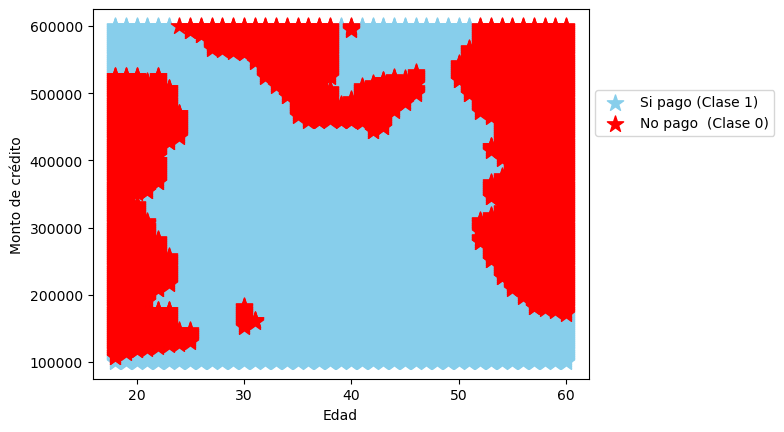

In [90]:
#Filtramos los pagadores de los deudores
buenos = todos[clases_resultantes==1]
malos = todos[clases_resultantes==0]

#Codigo de grafica
plt.scatter(buenos["edad"], buenos["credito"],
           marker="*", s=150, color="skyblue", 
           label ="Si pago (Clase 1)")

plt.scatter(malos["edad"], malos["credito"],
           marker="*", s=150, color="red", 
           label ="No pago  (Clase 0)")
plt.ylabel("Monto de crédito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1,0.8))
plt.show()